In [1]:
from Scripts.data_preprocessing_sber import preprocessing_data_from_sber

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
%matplotlib inline
from typing import Union,TypeVar
from datetime import datetime
import joblib
import sys
import json

import torch
from torch import optim
from torch.autograd import Variable, grad
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import rel_entr, kl_div
from scipy.spatial.distance import jensenshannon
from scipy.stats import kstest, ks_2samp, wasserstein_distance
import scipy.stats as sts
from tqdm import tqdm

from TRGAN.TRGAN_main_V2 import *
from TRGAN.encoders import *
import TRGAN.TRGAN_train_load_modules as trgan
from TRGAN.evaluation_metrics import *
from TRGAN.methods_comparison import *
from TRGAN.TRGAN_light_preprocessing import *
from TRGAN.data_preprocessing import load_data

import warnings
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
# DEVICE = 'cpu'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda:0


In [2]:
data = preprocessing_data_from_sber(folder_path=r'Data\Sber\ditry_single')
# data = preprocessing_data_from_sber(folder_path=r'Data\Sber\ditry') 

Ищем CSV-файлы в: c:\Users\kiril\TRGAN\Data\Sber\ditry_single
Найдено файлов: 1
Файлы: ['c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry_single\\transact1_2K.csv']
Загрузка и обработка файла: c:\Users\kiril\TRGAN\Data\Sber\ditry_single\transact1_2K.csv
Корректная обработка ADDRESS...
Статистика:
  Оффлайн транзакций: 70224 (21.7%)
  Онлайн транзакций: 253620 (78.3%)
  Физических адресов: 70218 (21.7%)
  Виртуальных транзакций: 253620 (78.3%)
Валидация логики обработки ADDRESS:
--------------------------------------------------
Онлайн транзакций: 253620
Онлайн транзакций, помеченных как виртуальные: 253620
Совпадение: 100.0%

Оффлайн транзакций: 70224
Оффлайн с физическими адресами: 70218
Покрытие: 100.0%

Распределение ADDRESS_TYPE:
ADDRESS_TYPE
VIRTUAL     253620
PHYSICAL     67241
OTHER         2977
MISSING          6
Name: count, dtype: int64
Итоговый датафрейм содержит 275259 строк и 36 колонок.


In [78]:
data["CITY"].unique()

array(['VIRTUAL', 'Санкт-Петербург', 'Металлострой', 'Приозерск',
       'UNKNOWN', 'Павловск', 'Пушкин', 'Всеволожск', 'Кириши',
       'Зеленогорск', 'Ломоносов', 'Сестрорецк', 'Коммунар', 'Шушары',
       'Колпино', 'Петергоф', 'Кронштадт', 'Стрельна', 'Мурино',
       'Парголово', 'Тельмана', 'Петродворец', 'Шлиссельбург', 'Гатчина',
       'Красное Село', 'Новое Девяткино', 'Калининград', 'Сертолово',
       'Горелово', 'Кудрово', 'Песочное', 'Песочный', 'Суходолье',
       'Херсонский', 'Ларионово', 'Сосново', 'Александровская', 'Репино',
       'Тосно', 'Кубинская', 'Белоостров', 'Разбегаево', 'Лисий Нос',
       'Молодежное', 'Виллози', 'Дони', 'Тихвин', 'Светлогорск', 'Беково',
       'Отрадное', 'Порошкино', 'Новоселье (Володарское с/п)',
       'Никольское', 'Приладожское', 'Невской губы В.О.', 'Кобралово',
       'Васкелово', 'Финского залива', 'Кисельня', 'Кировск', 'Чудово',
       'Смолячково', 'Борисово', 'Матокса', 'Гурьевск', 'Серово',
       'Пионерский', 'Лебяжье', 

In [79]:
data["REGION"].unique()

array(['VIRTUAL', 'Санкт-Петербург', 'обл Ленинградская', 'UNKNOWN',
       'обл Калининградская', 'обл Новгородская'], dtype=object)

In [80]:
data[data["REGION"] == 'UNKNOWN']

,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
2528960,1006209,394374368,1900-01-01 05:51:23,220.0,8999,220.0,Рубль,MasterCard,P1900018,"ул Малая Садовая, д 1/25, лит А.",...,1,3,1,0,1,0,1.0,5,51,23
149728,1000235,394372599,1900-01-01 06:36:07,1000.0,5541,1000.0,Рубль,MasterCard,P7500052,"ул. Красносельская, д. 151",...,1,2,1,0,1,0,1.0,6,36,7
2308802,1106036,394363124,1900-01-01 09:38:35,915.9,5641,915.9,Рубль,БАНК,P4800051,"пр. Кузнецова, д. 11/3",...,1,2,1,0,1,0,1.0,9,38,35
893917,1067080,394376759,1900-01-01 10:00:18,164.0,5921,164.0,Рубль,MasterCard,P6000028,ул.Инженерная д.23,...,1,1,1,0,1,0,1.0,10,0,18
143025,1000236,394366891,1900-01-01 10:41:25,748.0,5541,748.0,Рубль,MasterCard,P7500051,"ул. Красносельская, д. 151",...,1,2,1,0,1,0,1.0,10,41,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911401,1036294,803347528,1900-01-01 19:26:32,105.0,5411,105.0,Рубль,MasterCard,P6000024,ул.Юбилейная д.8а,...,1,1,1,0,1,0,1.0,19,26,32
3453219,1130180,803347522,1900-01-01 19:27:03,75.1,5641,75.1,Рубль,БАНК,P4800292,"ул. Уточкина, д.4, лит. А",...,1,3,1,0,1,0,1.0,19,27,3
1459638,1085688,803339104,1900-01-01 19:57:59,481.0,5641,481.0,Рубль,БАНК,M5500054,"пл Балканская,5,лит Д,",...,1,3,1,0,1,0,1.0,19,57,59
3194498,112224,803339684,1900-01-01 20:07:31,59.0,5411,59.0,Рубль,МИР - НСПК,M1900052,Ул. Караваевская д 24,...,1,1,1,0,1,0,1.0,20,7,31


In [81]:
data[data["ID"] == '803705691']

,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
2408463,1008017,803705691,1900-01-01 07:42:54,600.0,4814,600.0,Рубль,MasterCard,AC090945,"РОССИЯ,188689,обл Ленинградская,р-н Всеволожск...",...,1,7,1,0,1,0,1.0,7,42,54


In [82]:
data["ISVIRTUALTRANSACTION"].unique()

array([1, 0])

In [83]:

data.head()



,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
102275,1002034,395323719,1900-01-01,1000.91,5541,1000.91,Рубль,VISA International,17035001,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
110434,1002507,394223959,1900-01-01,2000.00,6536,2000.00,Рубль,MasterCard,virtual,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
110473,1004263,395308613,1900-01-01,59.00,5735,59.00,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
115262,1004720,395018586,1900-01-01,149.00,5735,149.00,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
125000,1001171,395018563,1900-01-01,59.00,5735,59.00,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0


In [84]:

data.describe()

,TRANS_TIME,AMOUNT_EQ,PAY_AMT,DATE,IS_OFFLINE,IS_ONLINE,HAS_ADDRESS,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
count,5869662,5.869662e+06,5.869662e+06,5869662,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06,5.869662e+06
mean,1900-01-01 14:42:57.934322432,6.641990e+02,6.598412e+02,2018-03-28 22:03:12.747862528,1.521774e-01,8.478226e-01,1.370771e-01,1.521774e-01,1.636216e+00,1.521774e-01,8.478226e-01,1.521774e-01,8.478226e-01,9.970951e-01,1.424221e+01,2.796741e+01,2.793291e+01
min,1900-01-01 00:00:00,1.000000e-02,1.000000e-02,2017-05-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,1900-01-01 12:04:58,1.760000e+02,1.740000e+02,2017-10-25 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.200000e+01,1.200000e+01,1.200000e+01
50%,1900-01-01 15:37:24,3.960000e+02,3.923850e+02,2018-04-13 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.500000e+01,2.800000e+01,2.800000e+01
75%,1900-01-01 18:41:52,9.000000e+02,9.000000e+02,2018-08-28 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.800000e+01,4.400000e+01,4.400000e+01
max,1900-01-01 23:59:59,5.377870e+03,3.653000e+03,2019-01-31 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.741318e+00,2.300000e+01,5.900000e+01,5.900000e+01
std,NaN,7.092457e+02,7.053000e+02,NaN,3.591928e-01,3.591928e-01,3.439287e-01,3.591928e-01,1.571832e+00,3.591928e-01,3.591928e-01,3.591928e-01,3.591928e-01,5.341231e-02,5.388637e+00,1.802876e+01,1.810204e+01


In [85]:
data.to_csv('Data/Sber/Clear/transact_all.csv', 
          index=False,           # Не записывать индексы
          sep=',',               # Разделитель
          encoding='utf-8',      # Кодировка
          header=True,           # Записывать заголовки
          na_rep='NULL')         # Замена NaN значений

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5869662 entries, 102275 to 3915025
Data columns (total 36 columns):
 #   Column                Dtype         
---  ------                -----         
 0   CustomerKey           object        
 1   ID                    object        
 2   TRANS_TIME            datetime64[ns]
 3   AMOUNT_EQ             float64       
 4   MCC                   object        
 5   PAY_AMT               float64       
 6   CurrencyName          object        
 7   PaymentSystem         object        
 8   TERMINAL_CODE         object        
 9   ADDRESS               object        
 10  DEVICETYPE            object        
 11  TRANS_DETAIL          object        
 12  NAME                  object        
 13  OpType                object        
 14  DETAILEDCARDTYPE      object        
 15  ISOWNTERMINAL         object        
 16  ACCOUNT_ID            object        
 17  CARD                  object        
 18  TRANMETHOD            object        
 19  

Среднее: 1.00
Медиана: 1.00
Мода: 1.00
Коэффициент асимметрии: -18.33


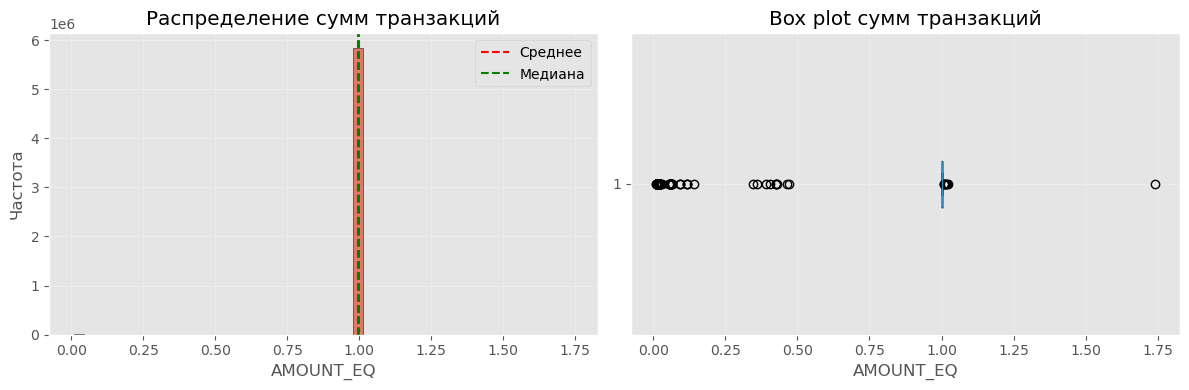

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew


amounts = data['EXCHANGE_RATA'].dropna()

print(f"Среднее: {amounts.mean():.2f}")
print(f"Медиана: {amounts.median():.2f}")
print(f"Мода: {amounts.mode().values[0]:.2f}")
print(f"Коэффициент асимметрии: {skew(amounts):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(amounts, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(amounts.mean(), color='red', linestyle='--', label='Среднее')
axes[0].axvline(amounts.median(), color='green', linestyle='--', label='Медиана')
axes[0].set_xlabel('AMOUNT_EQ')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение сумм транзакций')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(amounts, vert=False)
axes[1].set_xlabel('AMOUNT_EQ')
axes[1].set_title('Box plot сумм транзакций')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [88]:
data['CurrencyName'].unique()

array(['Рубль', 'Евро', 'Доллар США', 'Болгарский лев ',
       'Австралийский доллар', 'Чешская крона', 'Новая турецкая лира',
       'Украинская гривна', 'Злотый', 'Фунт стерлингов',
       'Канадский доллар', 'Китайский юань', 'Швейцарский франк',
       'Шведская крона', 'Бразильский реал', 'Иена'], dtype=object)

In [89]:
data[data['CurrencyName'] == 'Чешская крона']["EXCHANGE_RATA"]

2593974    0.426374
4309712    0.405812
4360431    0.390065
5218585    0.344299
5263130    0.360504
Name: EXCHANGE_RATA, dtype: float64

In [90]:
data['MCC'].nunique()
print(data['MCC'].nunique())

346


In [91]:
print("Минимальная дата:", data['DATE'].min())
print("Максимальная дата:", data['DATE'].max())
print("Пропущенные значения в DATE:", data['DATE'].isna().sum())

Минимальная дата: 2017-05-01 00:00:00
Максимальная дата: 2019-01-31 00:00:00
Пропущенные значения в DATE: 0


In [92]:
print("Уникальные клиенты:", data['ACCOUNT_ID'].nunique())
print("Транзакции на клиента:")
print(data['ACCOUNT_ID'].value_counts().describe())

Уникальные клиенты: 29987
Транзакции на клиента:
count    29987.000000
mean       195.740221
std        394.763679
min          3.000000
25%         17.000000
50%         73.000000
75%        274.000000
max      43080.000000
Name: count, dtype: float64


In [93]:
onehot_cols = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
cat_feat_names = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
num_feat_names = ['AMOUNT_EQ', 'HOUR', 'MINUTE', 'SECOND', 'EXCHANGE_RATA']
log1p_transform_cols = ['AMOUNT_EQ', 'EXCHANGE_RATA']  # если суммы имеют skewed распределение
date_feature = 'DATE'
time_feature = 'TRANS_TIME'
client_id = 'ACCOUNT_ID'
mcc_name = 'MCC'
latent_dim = {'onehot': 128, 'categorical': 16, 'numerical': 4, 'cv': 32}

In [94]:
print("Размер исходных данных:", data.shape)
print("Уникальные клиенты:", data[client_id].nunique())
print("Пропуски в client_id:", data[client_id].isna().sum())
print("Пропуски в date_feature:", data[date_feature].isna().sum())

# Проверим распределение транзакций по клиентам
client_transactions = data[client_id].value_counts()
print("\nРаспределение транзакций по клиентам:")
print(client_transactions.describe())

# Сколько клиентов имеют достаточно транзакций
min_transactions = 2  # минимум для вычисления интервалов
enough_data_clients = client_transactions[client_transactions >= min_transactions]
print(f"Клиенты с ≥{min_transactions} транзакциями: {len(enough_data_clients)}")

# Дополнительная диагностика
print(f"\nДополнительная информация:")
print(f"Тип данных {date_feature}: {data[date_feature].dtype}")
print(f"Тип данных {client_id}: {data[client_id].dtype}")

# Проверим первые несколько значений
print(f"\nПервые 5 значений {date_feature}:")
print(data[date_feature].head())
print(f"\nПервые 5 значений {client_id}:")
print(data[client_id].head())

Размер исходных данных: (5869662, 36)
Уникальные клиенты: 29987
Пропуски в client_id: 0
Пропуски в date_feature: 0

Распределение транзакций по клиентам:
count    29987.000000
mean       195.740221
std        394.763679
min          3.000000
25%         17.000000
50%         73.000000
75%        274.000000
max      43080.000000
Name: count, dtype: float64
Клиенты с ≥2 транзакциями: 29987

Дополнительная информация:
Тип данных DATE: datetime64[ns]
Тип данных ACCOUNT_ID: object

Первые 5 значений DATE:
102275   2017-05-01
110434   2017-05-01
110473   2017-05-01
115262   2017-05-01
125000   2017-05-01
Name: DATE, dtype: datetime64[ns]

Первые 5 значений ACCOUNT_ID:
102275    7807339
110434    6751581
110473    5324659
115262    1427713
125000    4679655
Name: ACCOUNT_ID, dtype: object


In [95]:

X_emb, X_oh, cond_vector, synth_date, scaler_cat, scaler_onehot, scaler_num, cv_params, scaler, round_array = \
            trgan.embeddings(data, cat_feat_names, num_feat_names, onehot_cols, date_feature, time_feature, client_id, latent_dim, device=DEVICE, load=False, epochs=60, directory='Pretrains_sber_all/')

Loss E_oh: 3.4965552231369657e-07: 100%|██████████| 60/60 [2:06:02<00:00, 126.04s/it]  


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.80 GiB. GPU 0 has a total capacity of 11.99 GiB of which 0 bytes is free. Of the allocated memory 25.85 GiB is allocated by PyTorch, and 16.78 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

dim_noise = 20
generator, supervisor, loss_array = trgan.train(X_emb, cond_vector, latent_dim, dim_noise, epochs=60, load=False, experiment_id='sber', DIRECTORY='Pretrains_sber_all/')

Discriminator Loss: -0.04834 || Discriminator 2 Loss: -0.00453 || Generator Loss: 0.00206 || Supervisor Loss: -0.00620: 100%|██████████| 60/60 [06:03<00:00,  6.06s/it] 


In [ ]:
n_samples = len(X_emb[:]) + 1000
print(n_samples)
synth_data, synth_date, params = sample(n_samples, generator, supervisor, dim_noise, cond_vector, X_emb, cv_params['encoder'], data,\
                                date_feature, client_id, cv_params=cv_params, device=DEVICE)



X_emb1 = scaler.inverse_transform(X_emb)
synth_data = scaler.inverse_transform(synth_data)
print(synth_data)
synth_df = inverse_transform(synth_data, latent_dim, X_oh.columns, scaler_onehot, scaler_cat, scaler_num, cat_feat_names,
                             mcc_name, num_feat_names, True, synth_date, time_feature, round_array, device=DEVICE)


276259
[[ 0.4056552   0.28801516 -0.6498334  ... -0.5354219  -0.03680103
  -0.8924478 ]
 [-0.21532129  0.88082683  0.23498778 ... -0.5360365  -0.01653705
  -0.8797016 ]
 [-0.91350824  0.99609214  0.96208864 ... -0.54026836 -0.03634509
  -0.7787172 ]
 ...
 [-0.97546005  0.9474264   0.9418216  ... -0.6662491  -0.40620366
  -0.8783561 ]
 [-0.9685808   0.98026323  0.91865456 ... -0.5598746  -0.15556078
  -0.8321167 ]
 [-0.956285    0.85567456  0.8497865  ... -0.6050286  -0.32499748
  -0.8533654 ]]


In [ ]:
synth_df['CurrencyName'].unique()

array(['Рубль', 'Доллар США', 'Евро'], dtype=object)

In [ ]:
synth_df[synth_df['CurrencyName'] == 'Евро']

,PaymentSystem,OpType,DETAILEDCARDTYPE,TRANMETHOD,ISOWNTERMINAL,NAME,MCC,DEVICETYPE,CurrencyName,CITY,REGION,ISVIRTUALTRANSACTION,ACCOUNT_ID,TERMINAL_CODE,CARD,TRANS_DETAIL,AMOUNT_EQ,EXCHANGE_RATA,DATE,TRANS_TIME
797,MasterCard,Оплата,MasterCard Standard,51,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,597862,11436154,3677463,"PYATEROCHKA 11996, SESTRORETSK, RU",598.85,0.999764,2018-02-22,17:35:35
940,MasterCard,Оплата,MasterCard Standard,50,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1737105,441843,2641843,"AO UK START, SANKT-PETERBU, RU",689.78,0.999822,2017-07-18,18:38:38
1577,MasterCard,Оплата,MasterCard Unembossed,70,0,Оплата товаров/услуг по карте,5331,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1434103,20196342,3924004,"TORGOVYI CENTR, PAVLOVSK, RU",980.24,0.999866,2018-04-20,19:44:44
2848,MasterCard,Оплата,MasterCard Standard,50,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1428812,10825944,1651616,"LIMAN, SANKT-PETERBU, RU",1155.66,0.999870,2017-07-26,19:47:47
3714,MasterCard,Оплата,MasterCard Standard,71,0,Оплата товаров/услуг по карте,5411,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,9115742,RZ100442,2501038,"AUCHAN PITER BOROVAJA, SAINT-PETERSB, RU",378.23,0.999693,2017-07-07,15:26:26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272932,MasterCard,Оплата,MasterCard Platinum,52,0,Оплата товаров/услуг по карте,5411,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,8947300,10922678,3095765,"BPMAZK BP 021, SANKT-PETERBU, RU",98.51,0.999084,2017-10-27,08:03:02
273954,MasterCard,Оплата,MasterCard Standard,50,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,2583970,10934759,2356580,"LAYM, SANKT-PETERBU, RU",276.53,0.999545,2017-07-19,13:20:19
273966,MasterCard,Оплата,MasterCard Unembossed,70,0,Оплата товаров/услуг по карте,5541,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,11257638,22118335,3961619,"OOO ""OKA REST"", TELMANA, RU",276.68,0.999544,2018-04-29,13:20:19
274333,MasterCard,Оплата,MasterCard Platinum,51,0,Оплата товаров/услуг по карте,5812,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1433389,10128797,3276135,"OOO FIALKA, SANKT-PETERBU, RU",141.90,0.999534,2017-12-03,11:08:08


In [ ]:
synth_df[synth_df['CurrencyName'] == 'Евро']

,PaymentSystem,OpType,DETAILEDCARDTYPE,TRANMETHOD,ISOWNTERMINAL,NAME,MCC,DEVICETYPE,CurrencyName,CITY,REGION,ISVIRTUALTRANSACTION,ACCOUNT_ID,TERMINAL_CODE,CARD,TRANS_DETAIL,AMOUNT_EQ,EXCHANGE_RATA,DATE,TRANS_TIME
797,MasterCard,Оплата,MasterCard Standard,51,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,597862,11436154,3677463,"PYATEROCHKA 11996, SESTRORETSK, RU",598.85,0.999764,2018-02-22,17:35:35
940,MasterCard,Оплата,MasterCard Standard,50,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1737105,441843,2641843,"AO UK START, SANKT-PETERBU, RU",689.78,0.999822,2017-07-18,18:38:38
1577,MasterCard,Оплата,MasterCard Unembossed,70,0,Оплата товаров/услуг по карте,5331,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1434103,20196342,3924004,"TORGOVYI CENTR, PAVLOVSK, RU",980.24,0.999866,2018-04-20,19:44:44
2848,MasterCard,Оплата,MasterCard Standard,50,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1428812,10825944,1651616,"LIMAN, SANKT-PETERBU, RU",1155.66,0.999870,2017-07-26,19:47:47
3714,MasterCard,Оплата,MasterCard Standard,71,0,Оплата товаров/услуг по карте,5411,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,9115742,RZ100442,2501038,"AUCHAN PITER BOROVAJA, SAINT-PETERSB, RU",378.23,0.999693,2017-07-07,15:26:26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272932,MasterCard,Оплата,MasterCard Platinum,52,0,Оплата товаров/услуг по карте,5411,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,8947300,10922678,3095765,"BPMAZK BP 021, SANKT-PETERBU, RU",98.51,0.999084,2017-10-27,08:03:02
273954,MasterCard,Оплата,MasterCard Standard,50,0,Оплата товаров/услуг по карте,1520,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,2583970,10934759,2356580,"LAYM, SANKT-PETERBU, RU",276.53,0.999545,2017-07-19,13:20:19
273966,MasterCard,Оплата,MasterCard Unembossed,70,0,Оплата товаров/услуг по карте,5541,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,11257638,22118335,3961619,"OOO ""OKA REST"", TELMANA, RU",276.68,0.999544,2018-04-29,13:20:19
274333,MasterCard,Оплата,MasterCard Platinum,51,0,Оплата товаров/услуг по карте,5812,VIRTUAL,Евро,VIRTUAL,VIRTUAL,1,1433389,10128797,3276135,"OOO FIALKA, SANKT-PETERBU, RU",141.90,0.999534,2017-12-03,11:08:08


In [ ]:
print(n_samples)

276259


In [ ]:
synth_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276259 entries, 0 to 276258
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   PaymentSystem         276259 non-null  object        
 1   OpType                276259 non-null  object        
 2   DETAILEDCARDTYPE      276259 non-null  object        
 3   TRANMETHOD            276259 non-null  object        
 4   ISOWNTERMINAL         276259 non-null  object        
 5   NAME                  276259 non-null  object        
 6   MCC                   276259 non-null  object        
 7   DEVICETYPE            276259 non-null  object        
 8   CurrencyName          276259 non-null  object        
 9   CITY                  276259 non-null  object        
 10  REGION                276259 non-null  object        
 11  ISVIRTUALTRANSACTION  276259 non-null  object        
 12  ACCOUNT_ID            276259 non-null  object        
 13 

In [ ]:
print(X_oh.columns)

Index(['PaymentSystem_MasterCard', 'PaymentSystem_VISA International',
       'PaymentSystem_БАНК', 'PaymentSystem_МИР - НСПК', 'OpType_Возврат',
       'OpType_Оплата', 'OpType_Отмена операции', 'OpType_Перевод',
       'OpType_Поступление средств', 'OpType_Снятие наличных',
       ...
       'CITY_Шлиссельбург', 'CITY_Шушары', 'REGION_UNKNOWN', 'REGION_VIRTUAL',
       'REGION_Санкт-Петербург', 'REGION_обл Калининградская',
       'REGION_обл Ленинградская', 'REGION_обл Новгородская',
       'ISVIRTUALTRANSACTION_0', 'ISVIRTUALTRANSACTION_1'],
      dtype='object', length=403)


In [ ]:
synth_df.to_csv('Data/synth_sber.csv', 
          index=False,           # Не записывать индексы
          sep=',',               # Разделитель
          encoding='utf-8',      # Кодировка
          header=True,           # Записывать заголовки
          na_rep='NULL')         # Замена NaN значений

In [ ]:
# for i in range(latent_dim['onehot'],X_emb1.shape[1]):
#     plt.hist(X_emb1[:, i], bins=40, alpha=0.7, density=True)
#     plt.hist(synth_data[:, i], bins=40, alpha=0.7, density=True)

#     plt.show()

In [ ]:
synth_df['DETAILEDCARDTYPE']

0               MasterCard Unembossed
1         МИР Классическая Зарплатная
2                    MasterCard World
3               MasterCard Unembossed
4         МИР Классическая Зарплатная
                     ...             
276254    МИР Классическая Зарплатная
276255    МИР Классическая Зарплатная
276256               MasterCard World
276257               MasterCard World
276258            MasterCard Business
Name: DETAILEDCARDTYPE, Length: 276259, dtype: object

In [ ]:
cat_feat_names

['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']

In [ ]:

# plot_hist_categorical(data, synth_df, "CustomerKey", 100)

In [ ]:
# plot_hist_categorical(data, synth_df, "ID", 5000)

In [ ]:
# synth_df.head()

In [ ]:
# synth_df["DEVICETYPE"].unique()

In [ ]:
# data["DEVICETYPE"].unique()

In [ ]:
# plot_hist_onehot(data, synth_df, "DEVICETYPE")
# plt.hist(data["ADDRESS"], alpha=0.6, label='Real', bins=np.arange(0, data["ADDRESS"].value_counts().shape[0], 10), color='black', rwidth=0.8, density=True)

In [ ]:
# plot_hist_categorical(data, synth_df, "ADDRESS", 100)


In [ ]:
# plot_hist_categorical(data, synth_df, "TERMINAL_CODE", 5000)

In [ ]:
# plot_hist_categorical(data, synth_df, "TRANS_DETAIL", 500)

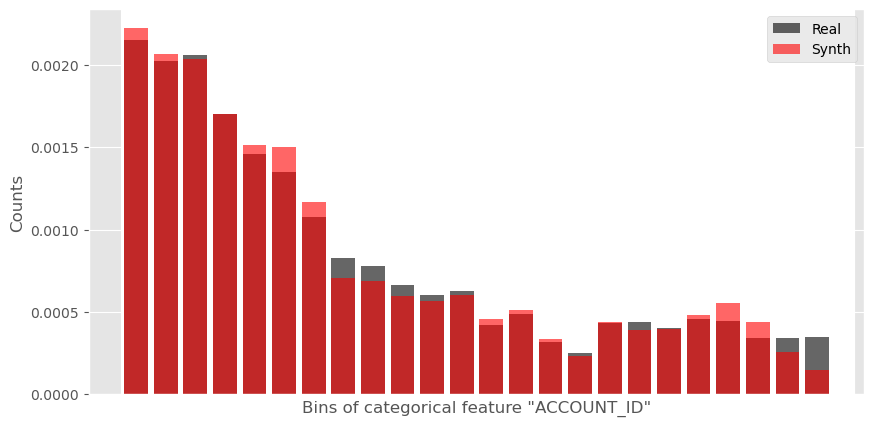

In [ ]:
plot_hist_categorical(data, synth_df, "ACCOUNT_ID", 50)

In [ ]:
# plot_hist_categorical(data, synth_df, "CARD", 50)

In [ ]:
num_feat_names

['AMOUNT_EQ', 'HOUR', 'MINUTE', 'SECOND', 'EXCHANGE_RATA']

In [ ]:
# plot_hist_numerical(data, synth_df, 'AMOUNT_EQ', tick=100)

In [ ]:
# evaluate_numerical([data['AMOUNT_EQ'], synth_df['AMOUNT_EQ']], ['Real', 'TRGAN'])

In [ ]:
onehot_cols

['PaymentSystem', 'OpType', 'DETAILED_CARD_TYPE', 'TRAN_METHOD', 'ISOWNTERMINAL', 'NAME', 'MCC']

['PaymentSystem',
 'OpType',
 'DETAILED_CARD_TYPE',
 'TRAN_METHOD',
 'ISOWNTERMINAL',
 'NAME',
 'MCC']

In [ ]:
# plot_hist_onehot(data, synth_df, 'MCC')

In [ ]:
# plot_hist_onehot(data, synth_df, 'NAME')

In [ ]:
# plot_hist_onehot(data, synth_df, 'ISOWNTERMINAL')

In [ ]:
# synth_df['TRANMETHOD'].unique()

In [ ]:
# plot_hist_onehot(data, synth_df, 'TRANMETHOD')

In [ ]:
# plot_hist_onehot(data, synth_df, 'DETAILEDCARDTYPE')

In [ ]:
# plot_hist_onehot(data, synth_df, 'OpType')

In [ ]:
# plot_hist_onehot(data, synth_df, 'PaymentSystem')